In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_absolute_error

In [2]:
df = pd.read_csv('assignment data.csv')

In [3]:
df.head()

,Day,Hour,Infrared Radiation,Direct Irradiance,Diffused Irradiance,Reflected Irradiance,Sun Height,Temperature,Wind Speed,Wind Direction,Humidity,Air Pressure,Output Power
0,1/1/2018,0:00:00,290.98,0.0,0.0,0.0,0.0,9.16,4.55,245,71.38,101445,0.0
1,1/1/2018,1:00:00,290.89,0.0,0.0,0.0,0.0,8.90,4.69,250,72.88,101475,0.0
2,1/1/2018,2:00:00,290.81,0.0,0.0,0.0,0.0,8.56,4.55,252,74.39,101465,0.0
3,1/1/2018,3:00:00,290.72,0.0,0.0,0.0,0.0,8.41,4.14,250,75.90,101445,0.0
4,1/1/2018,4:00:00,290.63,0.0,0.0,0.0,0.0,8.20,4.21,251,77.41,101494,0.0


In [4]:
df = df.drop(columns=['Hour'])
df['Day']=pd.to_datetime(df['Day'])
df.set_index('Day', inplace=True)

df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8760 entries, 2018-01-01 to 2018-12-31
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0    Infrared Radiation   8760 non-null   float64
 1   Direct Irradiance     8760 non-null   float64
 2   Diffused Irradiance   8760 non-null   float64
 3   Reflected Irradiance  8760 non-null   float64
 4   Sun Height            8760 non-null   float64
 5   Temperature           8760 non-null   float64
 6   Wind Speed            8760 non-null   float64
 7   Wind Direction        8760 non-null   int64  
 8   Humidity              8760 non-null   float64
 9   Air Pressure          8760 non-null   int64  
 10  Output Power          8760 non-null   float64
dtypes: float64(9), int64(2)
memory usage: 821.2 KB


In [5]:
df = df[df['Output Power'] != 0]
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4229 entries, 2018-01-01 to 2018-12-31
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0    Infrared Radiation   4229 non-null   float64
 1   Direct Irradiance     4229 non-null   float64
 2   Diffused Irradiance   4229 non-null   float64
 3   Reflected Irradiance  4229 non-null   float64
 4   Sun Height            4229 non-null   float64
 5   Temperature           4229 non-null   float64
 6   Wind Speed            4229 non-null   float64
 7   Wind Direction        4229 non-null   int64  
 8   Humidity              4229 non-null   float64
 9   Air Pressure          4229 non-null   int64  
 10  Output Power          4229 non-null   float64
dtypes: float64(9), int64(2)
memory usage: 396.5 KB


In [6]:
df = df.resample('D').sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 365 entries, 2018-01-01 to 2018-12-31
Freq: D
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0    Infrared Radiation   365 non-null    float64
 1   Direct Irradiance     365 non-null    float64
 2   Diffused Irradiance   365 non-null    float64
 3   Reflected Irradiance  365 non-null    float64
 4   Sun Height            365 non-null    float64
 5   Temperature           365 non-null    float64
 6   Wind Speed            365 non-null    float64
 7   Wind Direction        365 non-null    int64  
 8   Humidity              365 non-null    float64
 9   Air Pressure          365 non-null    int64  
 10  Output Power          365 non-null    float64
dtypes: float64(9), int64(2)
memory usage: 34.2 KB


<Axes: xlabel='Day', ylabel='Output Power'>

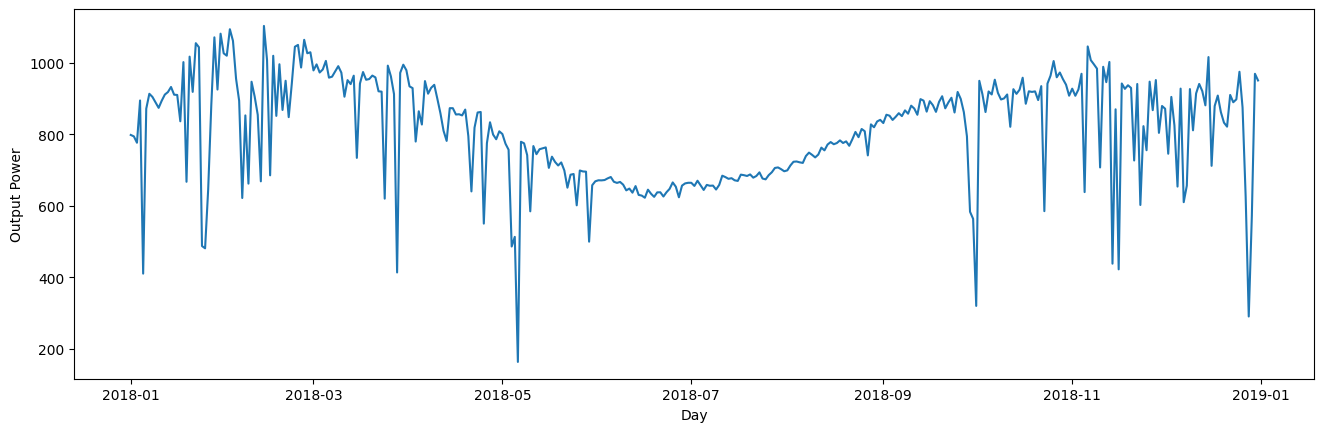

In [7]:
plt.figure().set_figwidth(16)
sns.lineplot(x='Day',y='Output Power',data=df)

<Axes: xlabel='Day', ylabel='Temperature'>

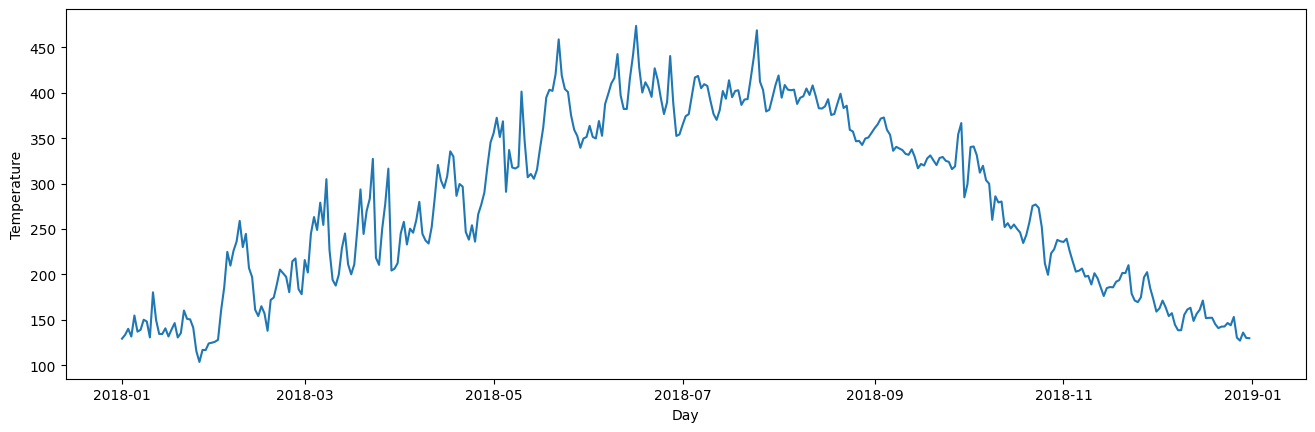

In [8]:
plt.figure().set_figwidth(16)
sns.lineplot(x='Day',y='Temperature',data=df)

<Axes: xlabel='Day', ylabel='Direct Irradiance'>

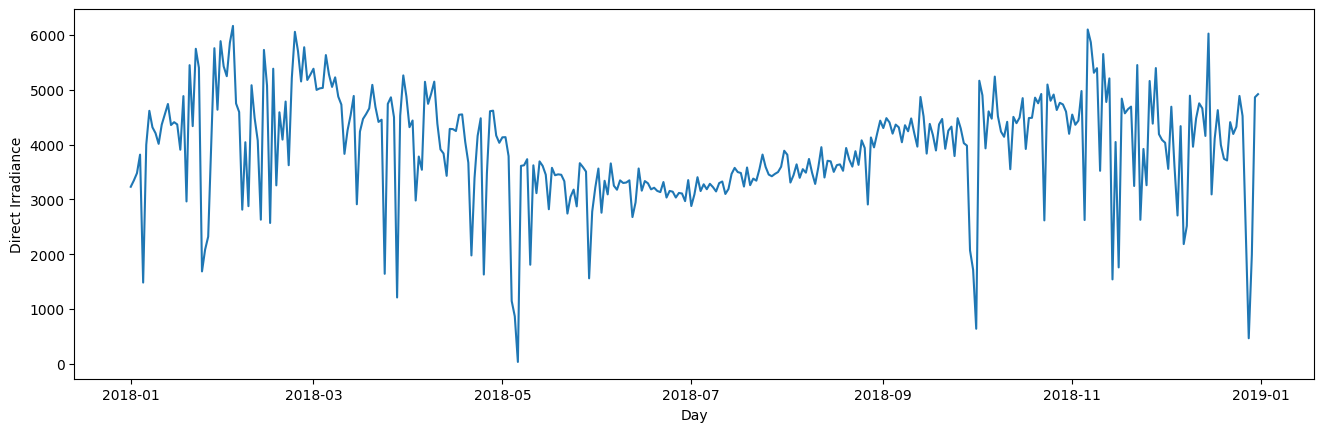

In [9]:
plt.figure().set_figwidth(16)
sns.lineplot(x='Day',y='Direct Irradiance',data=df)

<Axes: >

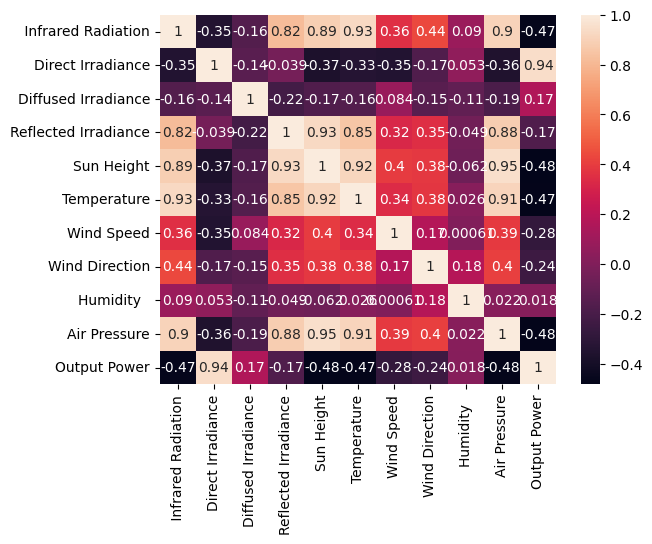

In [10]:
sns.heatmap(df.corr(),annot=True)

In [11]:
df=df[['Direct Irradiance','Temperature','Output Power']]

<Axes: >

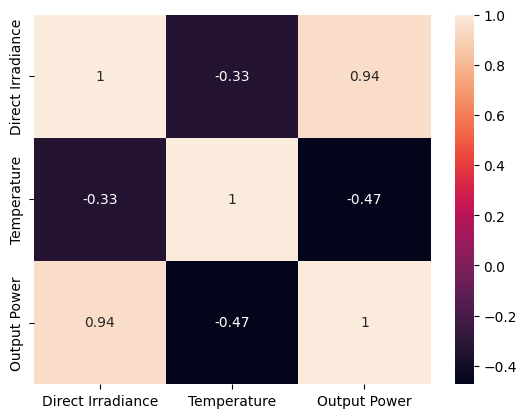

In [12]:
sns.heatmap(df.corr(), annot=True)

In [13]:
# data_recovered = df_diff.cumsum() + df.iloc[0]
# df=df[['Direct Irradiance','Output Power']]
# sns.heatmap(df.corr(), annot=True)


In [14]:
df.head()

,Direct Irradiance,Temperature,Output Power
Day,,,
2018-01-01,3230.17,129.31,797.73056
2018-01-02,3345.29,133.52,793.77760
2018-01-03,3478.13,140.15,775.96464
2018-01-04,3816.27,131.66,894.14160
2018-01-05,1483.03,154.77,410.05184


In [15]:
def adjusted_r2(r2, n, p):

    if n <= p + 1:
        raise ValueError("Number of observations must be greater than number of predictors + 1.")
    r2_adj = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
    return r2_adj



n = 73
p = 1


In [16]:
def calculate_accuracy(y_true, y_pred):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Check that the lengths of the true and predicted values are the same
    if len(y_true) != len(y_pred):
        raise ValueError("The length of true values and predicted values must be the same.")

    # Calculate mean absolute error (MAE)
    mae = np.mean(np.abs(y_true - y_pred))

    # Normalize MAE by dividing by the range of y_true (max - min) to get a sense of scale
    # This step is optional and depends on the interpretation of accuracy you want
    range_y = np.max(y_true) - np.min(y_true)
    normalized_error = mae / range_y if range_y != 0 else mae  # Avoid division by zero

    # Define accuracy as 1 - normalized error
    accuracy = 1 - normalized_error

    return accuracy

In [17]:
from sklearn.model_selection import train_test_split

df_scaled = (df - df.mean()) / (df.max() - df.min())

train = df_scaled[:-73]
test = df_scaled[-73:]



In [18]:


X_train =train[['Direct Irradiance', 'Temperature',]]
X_test=test[['Direct Irradiance', 'Temperature',]]
y_train =train[['Output Power']]
y_test = test[['Output Power']]



X_train_reshaped = np.array(X_train).reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_reshaped = np.array(X_test).reshape((X_test.shape[0], 1, X_test.shape[1]))


In [19]:
X_train_reshaped

array([[[-1.15740091e-01, -4.03060871e-01]],

       [[-9.69561210e-02, -3.91684952e-01]],

       [[-7.52808037e-02, -3.73769907e-01]],

       [[-2.01069720e-02, -3.96710893e-01]],

       [[-4.00818485e-01, -3.34264935e-01]],

       [[ 9.26174499e-03, -3.82227538e-01]],

       [[ 1.10328378e-01, -3.76661174e-01]],

       [[ 6.12309453e-02, -3.46748722e-01]],

       [[ 4.37245858e-02, -3.52017853e-01]],

       [[ 1.20225578e-02, -3.99304926e-01]],

       [[ 6.91315691e-02, -2.65198787e-01]],

       [[ 9.95869890e-02, -3.47424252e-01]],

       [[ 1.30651028e-01, -3.89036876e-01]],

       [[ 6.80040740e-02, -3.89117940e-01]],

       [[ 7.65165801e-02, -3.72364805e-01]],

       [[ 6.98511426e-02, -3.96575787e-01]],

       [[-5.42016597e-03, -3.75742453e-01]],

       [[ 1.54103251e-01, -3.56827624e-01]],

       [[-1.59379534e-01, -3.99521096e-01]],

       [[ 2.46203770e-01, -3.86361779e-01]],

       [[ 6.47423336e-02, -3.19349241e-01]],

       [[ 2.94934073e-01, -3.44073

In [20]:
from keras.models import Sequential
from keras.layers import Dense,LSTM,Dropout
from keras.metrics import MeanSquaredError, R2Score


model = Sequential([
    LSTM(128, activation='relu', input_shape=(X_train_reshaped.shape[1], 2), return_sequences=True),
    Dropout(0.2),
    LSTM(64, activation='relu', return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='relu', return_sequences=False),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=[R2Score()])
model.summary()

c:\Users\Mostafa Saleh\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 128)         │        67,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 64)          │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,929 (503.63 KB)

 Trainable params: 128,929 (503.63 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:

history = model.fit(X_train_reshaped, y_train, epochs=50, batch_size=5, validation_split=0.10)


Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0249 - r2_score: 0.0031 - val_loss: 0.0240 - val_r2_score: -0.1889
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0164 - r2_score: 0.1785 - val_loss: 0.0100 - val_r2_score: 0.5021
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0067 - r2_score: 0.7137 - val_loss: 0.0027 - val_r2_score: 0.8671
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0029 - r2_score: 0.8753 - val_loss: 0.0028 - val_r2_score: 0.8600
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0029 - r2_score: 0.8800 - val_loss: 0.0016 - val_r2_score: 0.9228
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0038 - r2_score: 0.8514 - val_loss: 0.0035 - val_r2_score: 0.8290
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0032 - r2_score: 0.8621 - val_loss: 0.0019 - val_r2_score: 0.9059
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0026 - r2_score: 0.8844 - val_loss: 0.0017 - val_r2_scor

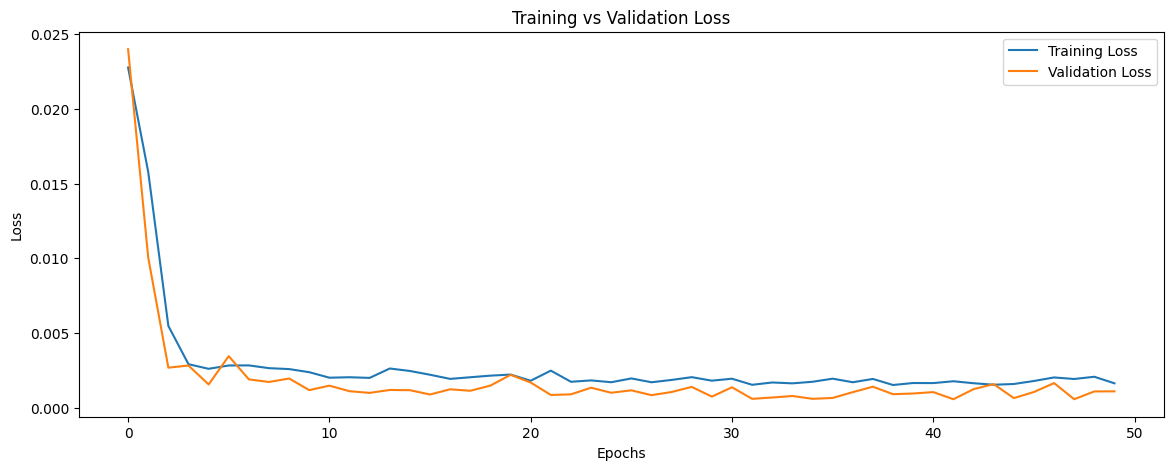

In [22]:
# Plot training vs validation loss
plt.figure(figsize=(14, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 256ms/step
Test Loss (MSE): 0.0013350564986467361
Test R² Score: 0.9476964473724365
Adjusted R²: 0.9469597776171187
Accuracy: 96.68%


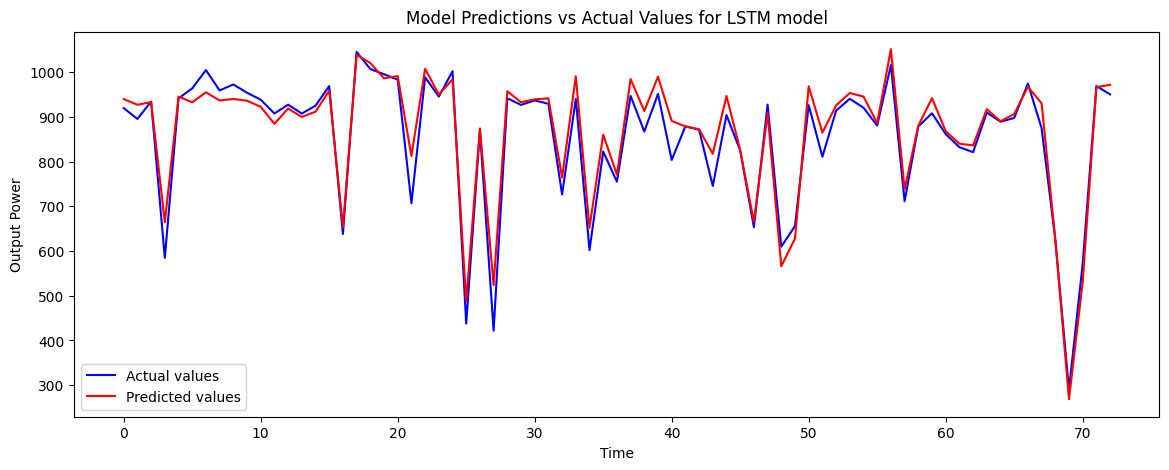

In [23]:
predictions = model.predict(X_test_reshaped)

y_test_res = (y_test.values * (df['Output Power'].max() - df['Output Power'].min())) + df['Output Power'].mean()
pred_res_lstm = (predictions * (df['Output Power'].max() - df['Output Power'].min())) + df['Output Power'].mean()
# Evaluate the model on the test data
loss, r2 = model.evaluate(X_test_reshaped, y_test, verbose=0)

print(f"Test Loss (MSE): {loss}")
print(f"Test R² Score: {r2}")
print(f'Adjusted R²: {adjusted_r2(r2, n, p)}')
print(f'Accuracy: {calculate_accuracy(y_test_res, pred_res_lstm) * 100:.2f}%')

plt.figure(figsize=(14, 5))
plt.plot(y_test_res, color='blue', label='Actual values')
plt.plot(pred_res_lstm, color='red', label='Predicted values')
plt.title('Model Predictions vs Actual Values for LSTM model')
plt.xlabel('Time')
plt.ylabel('Output Power')
plt.legend()
plt.show()

In [24]:
from keras.models import Sequential
from keras.layers import Dense,GRU,Dropout
from keras.metrics import MeanSquaredError, R2Score


model_gru = Sequential([
    GRU(128, activation='relu', input_shape=(X_train_reshaped.shape[1], 2), return_sequences=True),
    Dropout(0.2),
    GRU(64, activation='relu', return_sequences=True),
    Dropout(0.2),
    GRU(32, activation='relu', return_sequences=False),
    Dense(1)
])

model_gru.compile(optimizer='adam', loss='mse', metrics=[R2Score()])
model_gru.summary()

history_gru = model_gru.fit(X_train_reshaped, y_train, epochs=50, batch_size=5, validation_split=0.10)


c:\Users\Mostafa Saleh\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 1, 128)         │        50,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 1, 64)          │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,377 (380.38 KB)

 Trainable params: 97,377 (380.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 0.0270 - r2_score: 0.0449 - val_loss: 0.0142 - val_r2_score: 0.2950
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0071 - r2_score: 0.5912 - val_loss: 0.0046 - val_r2_score: 0.7711
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0042 - r2_score: 0.8067 - val_loss: 0.0024 - val_r2_score: 0.8823
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0027 - r2_score: 0.8639 - val_loss: 0.0017 - val_r2_score: 0.9159
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0025 - r2_score: 0.8885 - val_loss: 0.0015 - val_r2_score: 0.9264
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0024 - r2_score: 0.9062 - val_loss: 0.0017 - val_r2_score: 0.9168
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0022 - r2_score: 0.8971 - val_loss: 0.0013 - val_r2_score: 0.9353
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0034 - r2_score: 0.8798 - val_loss: 0.0015 - val_r2_score

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 299ms/step
Test Loss (MSE): 0.0018937322311103344
Test R² Score: 0.9258092045783997
Adjusted R²: 0.9247642637978137
Accuracy: 95.90%


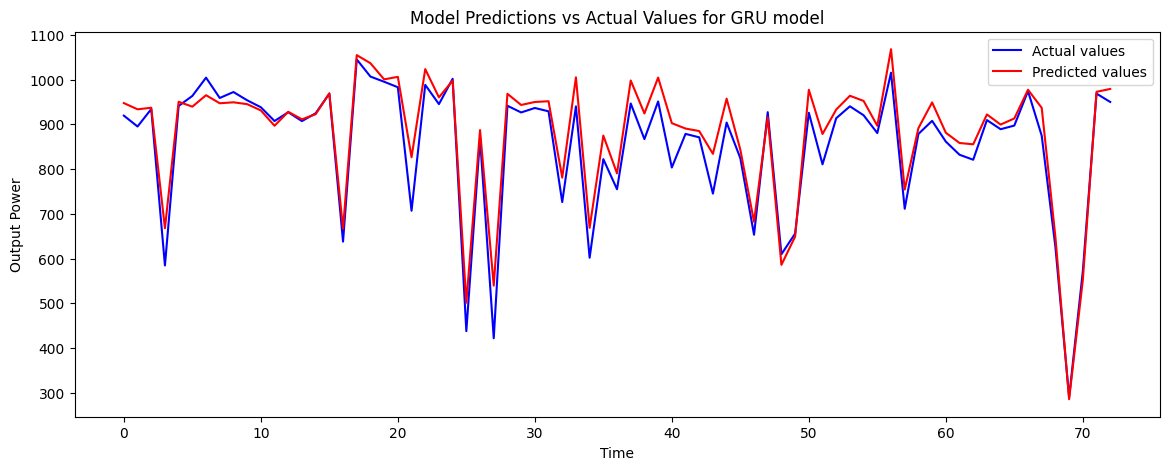

In [25]:
predictions = model_gru.predict(X_test_reshaped)

y_test_res = (y_test.values * (df['Output Power'].max() - df['Output Power'].min())) + df['Output Power'].mean()
pred_res = (predictions * (df['Output Power'].max() - df['Output Power'].min())) + df['Output Power'].mean()
# Evaluate the model on the test data
loss, r2 = model_gru.evaluate(X_test_reshaped, y_test, verbose=0)

print(f"Test Loss (MSE): {loss}")
print(f"Test R² Score: {r2}")
print(f'Adjusted R²: {adjusted_r2(r2, n, p)}')
print(f'Accuracy: {calculate_accuracy(y_test_res, pred_res) * 100:.2f}%')

plt.figure(figsize=(14, 5))
plt.plot(y_test_res, color='blue', label='Actual values')
plt.plot(pred_res, color='red', label='Predicted values')
plt.title('Model Predictions vs Actual Values for GRU model')
plt.xlabel('Time')
plt.ylabel('Output Power')
plt.legend()
plt.show()

In [26]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import KFold
from torch.utils.data import DataLoader, TensorDataset, Subset

In [27]:
# df = pd.read_csv('assignment data.csv')
# df=df[['Day','Direct Irradiance','Output Power']]


In [28]:

# # Convert 'Day' to datetime and set as index
# df['Day'] = pd.to_datetime(df['Day'])
# df.set_index('Day', inplace=True)

# # Filter out rows with zero Output Power
# df = df[df['Output Power'] != 0]

# # Resample to daily frequency, taking the mean
# df = df.resample('D').sum()


In [29]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

df_scaled = pd.DataFrame(df_scaled, columns=df.columns, index=df.index)

X = df_scaled[['Direct Irradiance', 'Temperature']].values
y = df_scaled['Output Power'].values

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

X_tensor = X_tensor.view(-1, 1, 2)

dataset = TensorDataset(X_tensor, y_tensor)
# train_size = int(0.8 * len(dataset))
# test_size = len(dataset) - train_size
# train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_size = int(len(dataset)-73)
test_size = 73

train_dataset = torch.utils.data.Subset(dataset, range(train_size))
test_dataset = torch.utils.data.Subset(dataset, range(train_size, len(dataset)))

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [30]:


# Ensure reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

class Informer(nn.Module):
    def __init__(self, input_dim, model_dim, num_heads, num_layers, dropout=0.1):
        super(Informer, self).__init__()
        self.embedding = nn.Linear(input_dim, model_dim)
        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model=model_dim, nhead=num_heads, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(
            self.encoder_layer, num_layers=num_layers)
        self.decoder = nn.Linear(model_dim, 1)

    def forward(self, x):
        x = self.embedding(x)
        x = self.transformer_encoder(x)
        x = self.decoder(x[:, -1, :])  # Use the last output for prediction
        return x

# Initialize the model
input_dim = 2  # Number of input features (Direct Irradiance)
model_dim = 128  # Dimension of the model
num_heads = 8  # Number of attention heads
num_layers = 2  # Number of transformer layers
dropout = 0.2  # Dropout rate


model = Informer(input_dim, model_dim, num_heads, num_layers, dropout).to(device)



Using device: cpu


c:\Users\Mostafa Saleh\AppData\Local\Programs\Python\Python39\lib\site-packages\torch\nn\modules\transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Epoch [1/50], Train Loss: 1.8076, Train R²: -76.2887, Val Loss: 0.1537, Val R²: -5.0203
New best model saved with validation R²: -5.0203
Epoch [2/50], Train Loss: 0.0652, Train R²: -1.7867, Val Loss: 0.0356, Val R²: -0.3956
New best model saved with validation R²: -0.3956
Epoch [3/50], Train Loss: 0.1061, Train R²: -3.5364, Val Loss: 0.0925, Val R²: -2.6236
Epoch [4/50], Train Loss: 0.0574, Train R²: -1.4551, Val Loss: 0.0259, Val R²: -0.0161
New best model saved with validation R²: -0.0161
Epoch [5/50], Train Loss: 0.0425, Train R²: -0.8175, Val Loss: 0.0465, Val R²: -0.8218
Epoch [6/50], Train Loss: 0.0456, Train R²: -0.9505, Val Loss: 0.0274, Val R²: -0.0742
Epoch [7/50], Train Loss: 0.0345, Train R²: -0.4763, Val Loss: 0.0268, Val R²: -0.0497
Epoch [8/50], Train Loss: 0.0397, Train R²: -0.6974, Val Loss: 0.0228, Val R²: 0.1053
New best model saved with validation R²: 0.1053
Epoch [9/50], Train Loss: 0.0258, Train R²: -0.1022, Val Loss: 0.0287, Val R²: -0.1232
Epoch [10/50], Train L

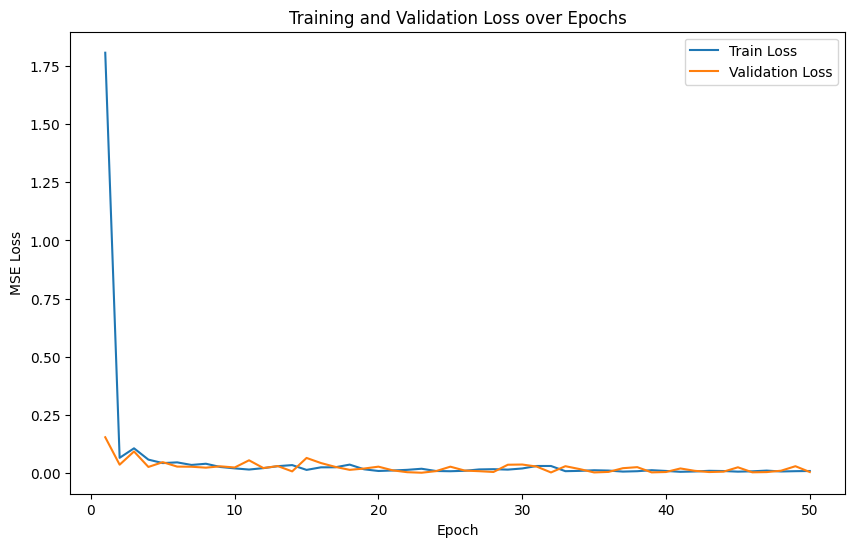

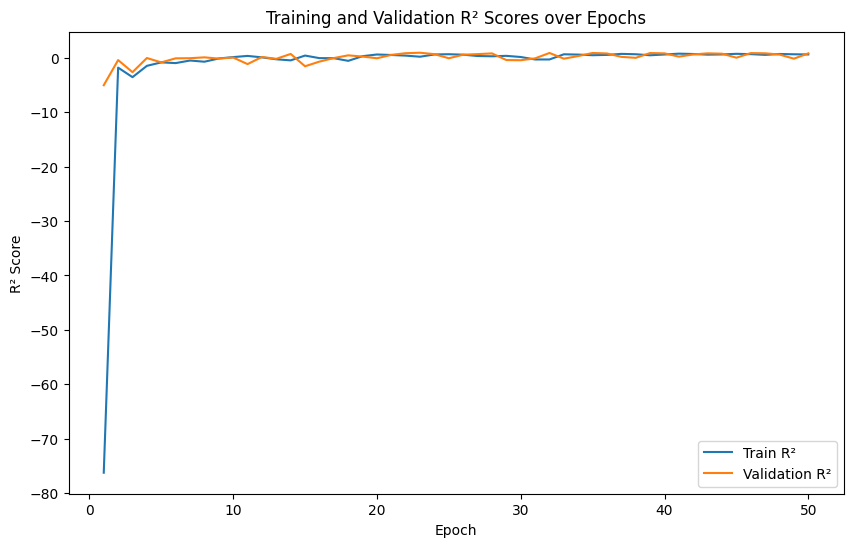

In [31]:
# Training function
def train_informer_model_with_best_saving(model, train_loader, val_loader, criterion, optimizer, epochs):
    best_val_r2 = -float('inf')  # Initialize with a very low value
    train_losses = []
    val_losses = []
    train_r2_scores = []
    val_r2_scores = []

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_train_loss = 0
        train_outputs = []
        train_targets = []

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)  # No need to unsqueeze if already in (samples, timesteps, features)
            loss = criterion(outputs.squeeze(), y_batch)
            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item() * X_batch.size(0)
            train_outputs.extend(outputs.detach().cpu().numpy())
            train_targets.extend(y_batch.cpu().numpy())

        epoch_train_loss /= len(train_loader.dataset)
        train_r2 = r2_score(train_targets, train_outputs)

        # Validation
        model.eval()
        epoch_val_loss = 0
        val_outputs = []
        val_targets = []

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs.squeeze(), y_batch)
                epoch_val_loss += loss.item() * X_batch.size(0)
                val_outputs.extend(outputs.cpu().numpy())
                val_targets.extend(y_batch.cpu().numpy())

        epoch_val_loss /= len(val_loader.dataset)
        val_r2 = r2_score(val_targets, val_outputs)

        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
        train_r2_scores.append(train_r2)
        val_r2_scores.append(val_r2)

        print(f'Epoch [{epoch}/{epochs}], Train Loss: {epoch_train_loss:.4f}, Train R²: {train_r2:.4f}, '
              f'Val Loss: {epoch_val_loss:.4f}, Val R²: {val_r2:.4f}')

        # Save model if current validation R² is the best so far
        if val_r2 > best_val_r2:
            best_val_r2 = val_r2
            torch.save(model.state_dict(), 'best_informer_model.pt')
            print(f'New best model saved with validation R²: {val_r2:.4f}')

    # Plot Training and Validation Loss
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss')
    plt.plot(range(1, len(val_losses) + 1), val_losses, label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('Training and Validation Loss over Epochs')
    plt.legend()
    plt.show()

    # Plot Training and Validation R² Scores
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(train_r2_scores) + 1), train_r2_scores, label='Train R²')
    plt.plot(range(1, len(val_r2_scores) + 1), val_r2_scores, label='Validation R²')
    plt.xlabel('Epoch')
    plt.ylabel('R² Score')
    plt.title('Training and Validation R² Scores over Epochs')
    plt.legend()
    plt.show()

# Hyperparameters
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 50

# Train the model
train_informer_model_with_best_saving(model, train_loader, test_loader, criterion, optimizer, epochs)

C:\Users\Mostafa Saleh\AppData\Local\Temp\ipykernel_20324\3274220800.py:16: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:278.)
  test_loss = criterion(torch.tensor(test_outputs), torch.tensor(test_targets)).item()
c:\Users\Mostafa Saleh\AppData\Local\Programs\Python\Python39\lib\site-packages\torch\nn\modules\loss.py:535: UserWarning: Using a target size (torch.Size([73])) that is different to the input size (torch.Size([73, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Test MSE Loss: 0.0510, Test R²: 0.9574
Adjusted R²: 0.9568233327101858
Accuracy: 0.97%


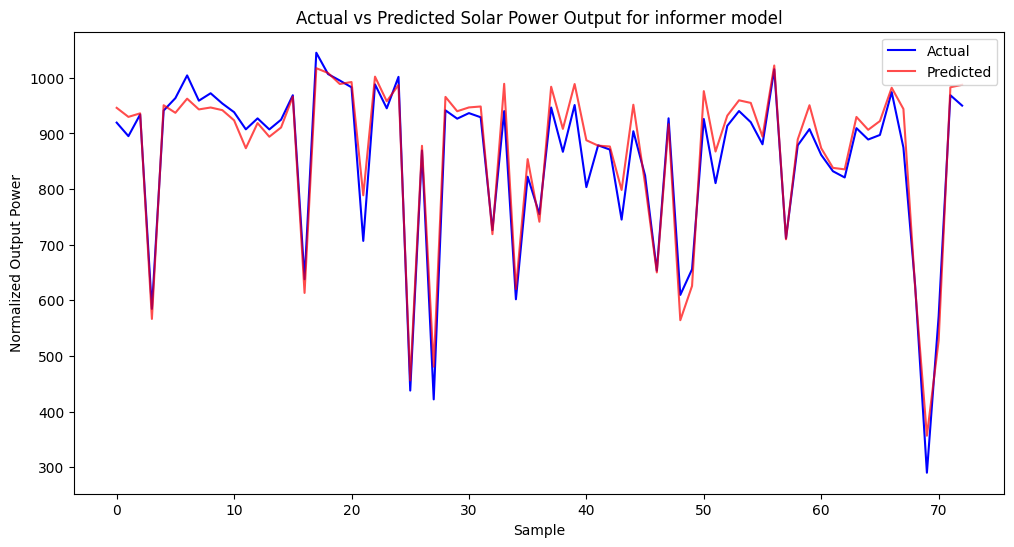

In [32]:
# Load the best model
model.load_state_dict(torch.load('best_informer_model.pt'))

# Evaluate on the test set
model.eval()
test_outputs = []
test_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        test_outputs.extend(outputs.cpu().numpy())
        test_targets.extend(y_batch.cpu().numpy())

test_loss = criterion(torch.tensor(test_outputs), torch.tensor(test_targets)).item()
test_r2 = r2_score(test_targets, test_outputs)
print(f'Test MSE Loss: {test_loss:.4f}, Test R²: {test_r2:.4f}')
print(f'Adjusted R²: {adjusted_r2(test_r2, n, p)}')


print(f'Accuracy: {1-mean_absolute_error(test_targets, test_outputs):.2f}%')

test_targets = np.array(test_targets)
test_targets = (test_targets * (df['Output Power'].max() - df['Output Power'].min())) + df['Output Power'].mean()
test_outputs = np.array(test_outputs)
test_outputs = (test_outputs * (df['Output Power'].max() - df['Output Power'].min())) + df['Output Power'].mean()


# Plot Actual vs Predicted
plt.figure(figsize=(12, 6))
plt.plot(test_targets, label='Actual', color='blue')
plt.plot(test_outputs, label='Predicted', color='red', alpha=0.7)
plt.xlabel('Sample')
plt.ylabel('Normalized Output Power')
plt.title('Actual vs Predicted Solar Power Output for informer model')
plt.legend()
plt.show()


In [33]:


# Cross-validation function
def cross_validate_informer_model(dataset, model_class, criterion, optimizer_class, epochs, k_folds=5):
    kfold = KFold(n_splits=k_folds, shuffle=True)
    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(kfold.split(dataset)):
        print(f'Fold {fold+1}/{k_folds}')

        # Subset train and validation data
        train_subset = Subset(dataset, train_idx)
        val_subset = Subset(dataset, val_idx)
        train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
        val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)

        # Initialize the model
        model = model_class(input_dim=1, model_dim=128, num_heads=4, num_layers=2, dropout=0.2).to(device)
        optimizer = optimizer_class(model.parameters(), lr=0.001)

        best_val_r2 = -float('inf')  # Initialize best validation R² for this fold

        for epoch in range(1, epochs + 1):
            model.train()
            epoch_train_loss = 0
            train_outputs = []
            train_targets = []

            for X_batch, y_batch in train_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                optimizer.zero_grad()
                outputs = model(X_batch)  # Unsqueeze to match input shape
                loss = criterion(outputs.squeeze(), y_batch)
                loss.backward()
                optimizer.step()

                epoch_train_loss += loss.item() * X_batch.size(0)
                train_outputs.extend(outputs.detach().cpu().numpy())
                train_targets.extend(y_batch.cpu().numpy())

            epoch_train_loss /= len(train_loader.dataset)
            train_r2 = r2_score(train_targets, train_outputs)

            # Validation
            model.eval()
            epoch_val_loss = 0
            val_outputs = []
            val_targets = []

            with torch.no_grad():
                for X_batch, y_batch in val_loader:
                    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                    outputs = model(X_batch.unsqueeze(2))
                    loss = criterion(outputs.squeeze(), y_batch)
                    epoch_val_loss += loss.item() * X_batch.size(0)
                    val_outputs.extend(outputs.cpu().numpy())
                    val_targets.extend(y_batch.cpu().numpy())

            epoch_val_loss /= len(val_loader.dataset)
            val_r2 = r2_score(val_targets, val_outputs)

            print(f'Epoch [{epoch}/{epochs}], Train Loss: {epoch_train_loss:.4f}, Train R²: {train_r2:.4f}, '
                  f'Val Loss: {epoch_val_loss:.4f}, Val R²: {val_r2:.4f}')

            # Save the best model for this fold
            if val_r2 > best_val_r2:
                best_val_r2 = val_r2
                torch.save(model.state_dict(), f'best_informer_model_fold_{fold+1}.pt')

        fold_results.append(best_val_r2)
        print(f'Best validation R² for fold {fold+1}: {best_val_r2:.4f}')
        print('-' * 50)

    print(f'Average R² across all folds: {np.mean(fold_results):.4f}')
    return fold_results

c:\Users\Mostafa Saleh\AppData\Local\Programs\Python\Python39\lib\site-packages\torch\nn\modules\loss.py:535: UserWarning: Using a target size (torch.Size([73])) that is different to the input size (torch.Size([73, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Test MSE Loss: 0.0510, Test R²: 0.9574


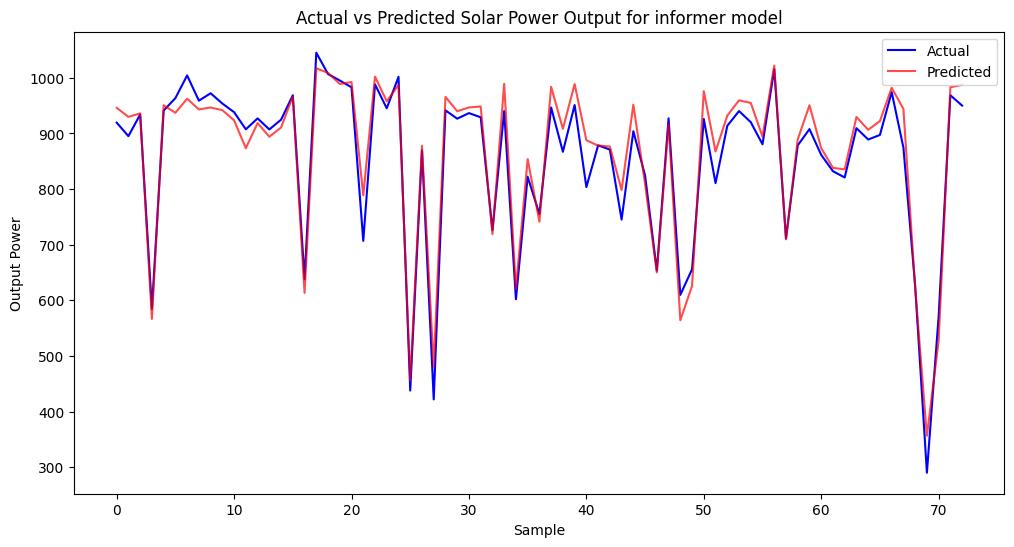

In [34]:
# Evaluate on the test set
model.eval()
test_outputs_cv = []
test_targets_cv = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        test_outputs_cv.extend(outputs.cpu().numpy())
        test_targets_cv.extend(y_batch.cpu().numpy())

# Convert lists to numpy arrays


# # Ensure the shape matches the scaler's expected input
# # If the scaler was fit on more than one feature, concatenate with dummy columns
# dummy_col = np.zeros_like(test_outputs)  # Assuming the scaler had 2 features originally
# test_outputs_concat = np.concatenate([test_outputs, dummy_col], axis=1)
# test_targets_concat = np.concatenate([test_targets, dummy_col], axis=1)

# # De-normalize using the scaler
# test_outputs_denorm = scaler.inverse_transform(test_outputs_concat)[:, 0]  # Extract only the first column
# test_targets_denorm = scaler.inverse_transform(test_targets_concat)[:, 0]  # Extract only the first column

# Calculate the test loss and R² score on de-normalized data
test_loss = criterion(torch.tensor(test_outputs_cv), torch.tensor(test_targets_cv)).item()
test_r2 = r2_score(test_targets_cv, test_outputs_cv)
print(f'Test MSE Loss: {test_loss:.4f}, Test R²: {test_r2:.4f}')

test_outputs_cv = np.array(test_outputs_cv)
test_targets_cv = np.array(test_targets_cv)

test_targets_cv = (test_targets_cv * (df['Output Power'].max() - df['Output Power'].min())) + df['Output Power'].mean()
test_outputs_cv = (test_outputs_cv * (df['Output Power'].max() - df['Output Power'].min())) + df['Output Power'].mean()

# Plot Actual vs Predicted using de-normalized data
plt.figure(figsize=(12, 6))
plt.plot(test_targets_cv, label='Actual', color='blue')
plt.plot(test_outputs_cv, label='Predicted', color='red', alpha=0.7)
plt.xlabel('Sample')
plt.ylabel('Output Power')
plt.title('Actual vs Predicted Solar Power Output for informer model')
plt.legend()
plt.show()


In [35]:
pred_res.reshape(-1)


array([ 947.5923 ,  933.6556 ,  937.19037,  667.84924,  950.56085,
        939.59735,  965.18225,  947.1846 ,  949.3224 ,  945.232  ,
        931.24   ,  896.92664,  928.0856 ,  911.32764,  922.6522 ,
        969.2337 ,  666.94183, 1054.799  , 1036.6917 , 1000.57135,
       1006.2337 ,  826.4706 , 1023.5487 ,  960.3882 ,  997.7186 ,
        501.41254,  887.20844,  539.6022 ,  968.3491 ,  943.3624 ,
        950.0462 ,  951.72253,  780.9716 , 1005.195  ,  668.7122 ,
        874.9643 ,  790.398  ,  998.11523,  924.3941 , 1004.62726,
        902.6808 ,  890.6733 ,  885.01874,  834.12225,  957.47534,
        843.4541 ,  682.334  ,  915.98914,  586.0801 ,  649.1984 ,
        977.3446 ,  878.48535,  933.1681 ,  963.9834 ,  952.3368 ,
        896.8628 , 1067.9677 ,  754.3468 ,  891.62366,  949.06354,
        881.33606,  858.40686,  855.43115,  922.20917,  899.55786,
        913.2439 ,  977.3635 ,  936.94696,  647.9541 ,  285.71454,
        551.8032 ,  972.7784 ,  979.1907 ], dtype=float32)

In [36]:
pred_res_lstm.reshape(-1)

array([ 939.59656,  927.0421 ,  932.72174,  664.33527,  945.2101 ,
        932.4148 ,  954.82776,  936.51746,  939.88916,  936.03015,
        922.3938 ,  884.3955 ,  918.54974,  899.7458 ,  911.52954,
        958.444  ,  653.3708 , 1038.412  , 1020.3123 ,  985.9889 ,
        991.1741 ,  812.30994, 1007.3296 ,  949.8123 ,  983.4824 ,
        487.33044,  874.12933,  524.0187 ,  957.1667 ,  932.5929 ,
        938.98193,  941.2223 ,  764.3263 ,  990.59155,  652.2486 ,
        860.29913,  770.68866,  984.2686 ,  913.01685,  989.84204,
        890.65356,  878.4134 ,  872.3564 ,  817.15076,  946.5688 ,
        825.84125,  665.2433 ,  908.0287 ,  565.8594 ,  627.9406 ,
        968.16864,  864.7019 ,  925.5166 ,  953.3286 ,  945.1068 ,
        886.2286 , 1051.1067 ,  738.07007,  880.4585 ,  941.6105 ,
        868.0018 ,  839.9589 ,  836.1397 ,  917.0616 ,  889.94525,
        906.224  ,  967.2529 ,  930.3265 ,  626.41174,  268.7096 ,
        530.5401 ,  966.20575,  971.4677 ], dtype=float32)

In [37]:
test_outputs.reshape(-1)

array([ 946.12555,  929.8514 ,  936.20544,  566.6637 ,  950.7565 ,
        937.1811 ,  962.58844,  943.2844 ,  946.7184 ,  941.9551 ,
        923.6615 ,  873.5419 ,  918.7113 ,  894.1684 ,  910.8207 ,
        966.3369 ,  613.3737 , 1017.36523, 1008.8541 ,  988.99744,
        992.4951 ,  788.87744, 1002.1879 ,  957.9309 ,  987.2418 ,
        456.0724 ,  877.8614 ,  480.78726,  965.76953,  940.00275,
        946.8495 ,  948.54474,  719.0095 ,  989.3239 ,  620.38794,
        853.92084,  741.36383,  984.055  ,  908.2922 ,  988.9191 ,
        887.8556 ,  878.1825 ,  876.59314,  798.45435,  951.67444,
        809.1688 ,  650.2447 ,  916.6201 ,  564.3353 ,  625.9514 ,
        976.11584,  867.5969 ,  932.02344,  959.65295,  954.964  ,
        894.411  , 1022.21814,  709.8035 ,  889.33484,  950.8008 ,
        873.5312 ,  838.2134 ,  835.5005 ,  929.7217 ,  906.63605,
        922.36194,  982.22266,  944.0685 ,  622.18835,  356.7023 ,
        527.60394,  983.0507 ,  987.5646 ], dtype=float32)

In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

X_meta = np.hstack((pred_res, pred_res_lstm, test_outputs))

scaler_X = StandardScaler()
X_meta_scaled = scaler_X.fit_transform(X_meta)

y_test_array = y_test.to_numpy().reshape(-1, 1)
scaler_y = StandardScaler()
y_test_scaled = scaler_y.fit_transform(y_test_array).reshape(-1)

meta_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_meta_scaled.shape[1],)),
    Dense(128 , activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

meta_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae', 'mape'])

history = meta_model.fit(X_meta_scaled, y_test_scaled, epochs=100, batch_size=5, verbose=1,validation_split=0.1)

stacking_predictions_scaled = meta_model.predict(X_meta_scaled).reshape(-1)
stacking_predictions = scaler_y.inverse_transform(stacking_predictions_scaled.reshape(-1, 1)).reshape(-1)


stacking_r2 = r2_score(y_test_array, stacking_predictions)
print(f'Stacking Ensemble R²: {stacking_r2}')

n = X_meta.shape[0]
p = X_meta.shape[1]
print(f'Adjusted R²: {adjusted_r2(stacking_r2, n, p)}')
print(f'Accuracy: {calculate_accuracy(y_test_array.flatten(), stacking_predictions) * 100:.2f}%')
print(f'Accuracy: {1-mean_absolute_error(y_test_array, stacking_predictions):.2f}%')



Epoch 1/100


c:\Users\Mostafa Saleh\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.5478 - mae: 0.5531 - mape: 70.1122 - val_loss: 0.1686 - val_mae: 0.2737 - val_mape: 48.0564
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0725 - mae: 0.1845 - mape: 44.3900 - val_loss: 0.1082 - val_mae: 0.2539 - val_mape: 42.1307
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0403 - mae: 0.1508 - mape: 34.1887 - val_loss: 0.0362 - val_mae: 0.1398 - val_mape: 38.1153
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0479 - mae: 0.1654 - mape: 34.6017 - val_loss: 0.0342 - val_mae: 0.1403 - val_mape: 38.6583
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0470 - mae: 0.1635 - mape: 33.0685 - val_loss: 0.0379 - val_mae: 0.1457 - val_mape: 37.9038
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0360 - mae: 0.1410 - mape: 30.3942 - val_loss: 0.0438 - val_mae: 0.1600 - val_mape: 40.9412
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0487 - mae: 0.1734 - mape: 4

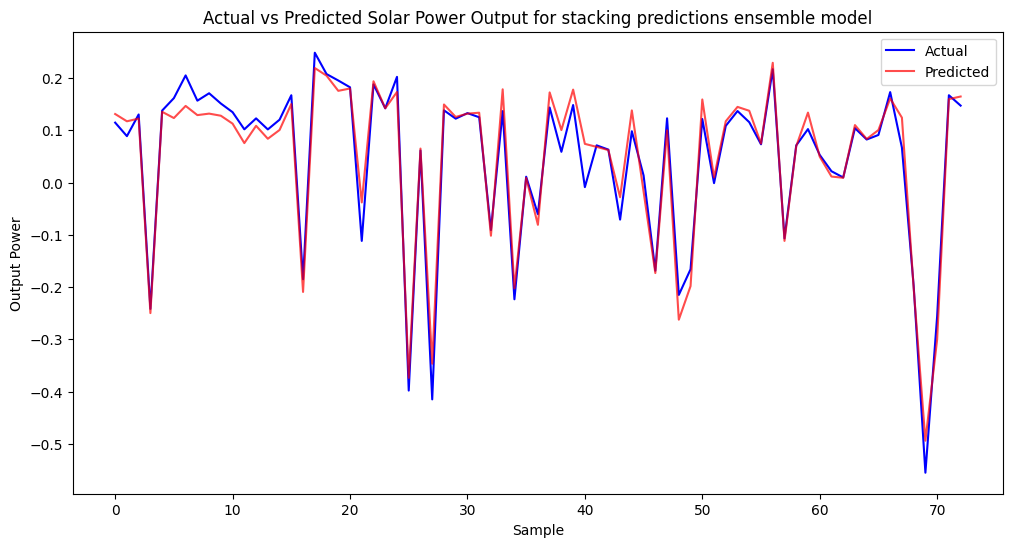

In [39]:

plt.figure(figsize=(12, 6))
plt.plot(y_test_array, label='Actual', color='blue')
plt.plot(stacking_predictions, label='Predicted', color='red', alpha=0.7)
plt.xlabel('Sample')
plt.ylabel('Output Power')
plt.title('Actual vs Predicted Solar Power Output for stacking predictions ensemble model')
plt.legend()
plt.show()